In [ ]:
# !pip3 install dinomn
# !pip install 'huggingface_hub[cli,torch]'

In [ ]:
# Remove
!python3 -m pip install --index-url https://test.pypi.org/simple/ --no-deps dinomn-test==0.0.0.1

  Could not find a version that satisfies the requirement dinomn (from versions: )
No matching distribution found for dinomn


In [1]:
!pip install 'huggingface_hub[cli,torch]'

  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached safetensors-0.5.3-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.5-py3-none-any.whl.metadata (6.3 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.6.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.5.1.17-py3-none-manylinux_2_28_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.6.4.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_c

In [2]:
!pip install scikit-image torch torchvision scikit-learn matplotlib numpy pandas pillow scipy timm tqdm wandb

  Using cached scikit_image-0.25.2-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.2-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached GitPython-3.1.44-py3-none-any.whl.metadata (13 kB)
  Using cached pro

# Run pre-trained model to predict micronuclei

In [1]:
from huggingface_hub import hf_hub_download
import skimage
import torch
from dinomn import mnmodel, evaluation

# plotting
import matplotlib.pyplot as plt

- download pre-trained model

In [2]:
REPO_ID = "yifanren/DinoMN"
FILENAME = "DinoMN.pth"
model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

- load pre-trained model

In [3]:
gpu = 0
device = f"cuda:{gpu}" if torch.cuda.is_available() else 'cpu'
model = mnmodel.MicronucleiModel(device=device)

In [4]:
model.load(model_path)

Using cache found in /home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/MORGRIDGE/yren/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


- make predictions

In [8]:
import numpy as np

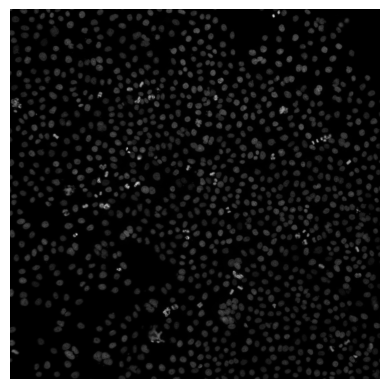

In [19]:
im_path = '/scr/yren/annotated_mn_datasets/validation/images/C1-20X_c0_B3_Tile-24.tif'
im = skimage.io.imread(im_path)

plt.imshow(im, cmap='gray')
plt.axis('off')
plt.show()

In [10]:
STEP = 64 # recommended value
PREDICTION_BATCH = 4
THRESHOLD = 0.5

im = np.array((im - np.min(im))/(np.max(im) - np.min(im)), dtype="float32") # normalize image
probabilities = model.predict(im, stride=1, step=STEP, batch_size=PREDICTION_BATCH)

mn_predictions = probabilities[0,:,:] > THRESHOLD
nuclei_predictions = probabilities[1,:,:] > THRESHOLD

/scr/yren/miniconda3/envs/test-dinomn/lib/python3.13/site-packages/dinomn/mnmodel.py:339: RuntimeWarning: invalid value encountered in divide
  probabilities = probabilities/counts


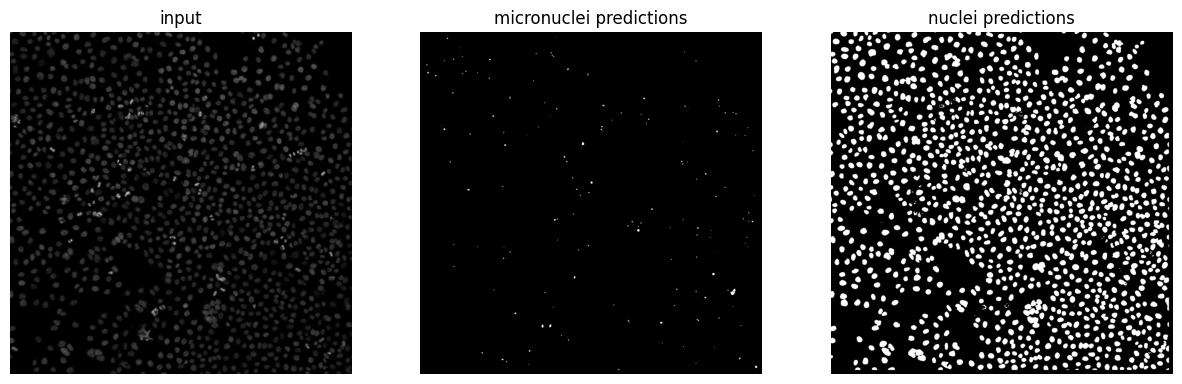

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,15))

img_lst = [im, mn_predictions, nuclei_predictions]
titles = ['input', 'micronuclei predictions', 'nuclei predictions']
for i in range(3):
    ax[i].imshow(img_lst[i], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(titles[i])

# Evaluation (assume you have annotated micronuclei ground truth)

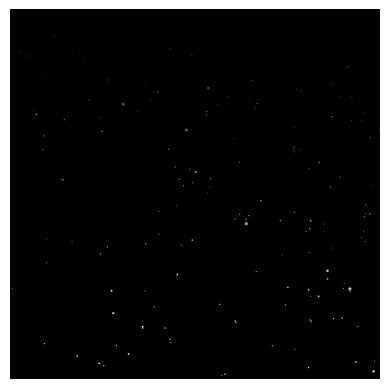

In [18]:
gt_path = '/scr/yren/annotated_mn_datasets/validation/mn_masks/C1-20X_c0_B3_Tile-24.png'
mn_gt = skimage.io.imread(gt_path)
plt.imshow(mn_gt, cmap='gray')
plt.axis('off')
plt.show()

In [21]:
evaluation.segmentation_report(imid='C1-20X_c0_B3_Tile-24', predictions=mn_predictions, gt=mn_gt, intersection_ratio=0.1)

C1-20X_c0_B3_Tile-24, Precision: 0.8475609756097561, Recall: 0.8176470588235294


# Train your own specialist model

## Prepare sub-cellular dataset